# MVP-2 — Experimento 3v2: Encoder Metilación PCA+MLP (Revisado)

**Cambios respecto a v1:**
1. **PCA variance sweep:** 85%, 90%, 95% — para encontrar el sweet spot entre compresión y señal
2. **Arquitectura más austera:** hidden_dim 128 (vs 256), z_dim 128 con proyección a 256 para fusión
3. **Regularización más agresiva:** weight_decay 1e-3 (vs 1e-4), dropout_input 0.6 (vs 0.5)
4. **CORAL opcional:** penalización suave para alinear distribuciones de study_part en z_met
5. **Diagnóstico por fold detallado:** composición de study_part, PDL distribution, domain shift metrics

**Hipótesis principal:** El v1 falló en Folds 1/2 por domain shift (study_part), no por capacidad insuficiente.
Reducir PCA components limita cuánta información de dominio llega al MLP.
Reducir capacidad del MLP limita cuánto puede memorizar esa información.

**Expectativa realista:** Mejorar Folds 1/2 moderadamente. No esperamos superar PCA+EN baseline (0.772).
Si no mejora, cerramos como resultado negativo útil.

## Sección 0: Configuración

In [1]:
import os, sys, json, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Device: mps
PyTorch: 2.2.2
Timestamp: 2026-04-02 18:25


## Sección 1: Rutas y parámetros

In [2]:
# --- RUTAS (AJUSTAR) ---
DATA_DIR     = Path("/Users/JCB/Documentos/Proyecto Integrador/data/")
MANIFEST_DIR = DATA_DIR / "manifests"
RESULTS_DIR  = Path("/Users/JCB/Documentos/Proyecto Integrador/results_2/")
OUTPUT_DIR   = RESULTS_DIR / "mvp2_encoder_met_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(exist_ok=True)

# --- ARCHIVOS ---
MANIFEST_PRETRAIN = "manifest_mvp2_pretrain_20260328_143235.csv"
MANIFEST_FINETUNE = "manifest_mvp2_finetune_20260328_143235.csv"
MET_MATRIX_FILE   = "mvp2_met_selected_20260328_143235.csv.gz"

# --- PCA SWEEP ---
PCA_VARIANTS = {
    '85pct': 0.85,   # ~8 PCs (baseline PCA+EN level)
    '90pct': 0.90,   # ~12-15 PCs (intermediate)
    '95pct': 0.95,   # ~19-24 PCs (v1 level)
}

# --- HIPERPARÁMETROS v2 (más austeros que v1) ---
HP = {
    # Arquitectura — REDUCIDA vs v1
    "hidden_dim":      128,    # v1: 256
    "z_dim":           128,    # interno — se proyecta a 256 para fusión
    "fusion_dim":      256,    # dimensión final para compatibilidad con z_img/z_rna
    "pdl_head_dim":    32,     # v1: 64
    "dropout_input":   0.6,    # v1: 0.5
    "dropout_hidden":  0.4,    # v1: 0.3

    # Training - Stage 1 (PRETRAIN)
    "lr_pretrain":      1e-3,
    "wd_pretrain":      1e-3,   # v1: 1e-4 — 10x más agresivo
    "epochs_pretrain":  200,
    "patience_pretrain": 25,
    "batch_size_pretrain": 64,

    # Training - Stage 2 (FINETUNE)
    "lr_finetune":      1e-4,
    "wd_finetune":      1e-3,   # v1: 1e-4
    "epochs_finetune":  150,
    "patience_finetune": 15,    # v1: 20 — más severo
    "batch_size_finetune": 32,

    # Loss
    "lambda_rank":     0.5,
    "rank_margin":     0.1,

    # CORAL (opcional — se prueba con y sin)
    "lambda_coral":    0.0,    # 0.0 = desactivado, probar 0.01-0.1

    "seed": SEED,
}

TARGETS = {
    "spearman_aspiracional": 0.695,
    "spearman_piso":         0.55,
    "worst_fold_aspiracional": 0.55,
    "worst_fold_piso":         0.45,
    "delta_auc_condicional":   0.10,
    "overfitting_gap":         0.15,
    "clock_rho_parcial":       0.30,
}

# Referencia v1
V1_RESULTS = {
    'mean': 0.5582, 'worst': 0.3035,
    'by_fold': {0: 0.9710, 1: 0.4000, 2: 0.3035},
    'batch_delta': {0: 0.289, 1: 0.212, 2: 0.462},
}
BASELINE_EN = {'mean': 0.772, 'worst': 0.610}

print("Hiperparámetros v2 (cambios vs v1 marcados):")
v1_hp = {'hidden_dim':256,'z_dim':256,'pdl_head_dim':64,'dropout_input':0.5,
         'dropout_hidden':0.3,'wd_pretrain':1e-4,'wd_finetune':1e-4,'patience_finetune':20}
for k, v in HP.items():
    marker = ''
    if k in v1_hp and v1_hp[k] != v:
        marker = f'  ← v1: {v1_hp[k]}'
    print(f"  {k}: {v}{marker}")
print(f"\nPCA sweep: {list(PCA_VARIANTS.keys())}")
print(f"\nTargets: {TARGETS}")

Hiperparámetros v2 (cambios vs v1 marcados):
  hidden_dim: 128  ← v1: 256
  z_dim: 128  ← v1: 256
  fusion_dim: 256
  pdl_head_dim: 32  ← v1: 64
  dropout_input: 0.6  ← v1: 0.5
  dropout_hidden: 0.4  ← v1: 0.3
  lr_pretrain: 0.001
  wd_pretrain: 0.001  ← v1: 0.0001
  epochs_pretrain: 200
  patience_pretrain: 25
  batch_size_pretrain: 64
  lr_finetune: 0.0001
  wd_finetune: 0.001  ← v1: 0.0001
  epochs_finetune: 150
  patience_finetune: 15  ← v1: 20
  batch_size_finetune: 32
  lambda_rank: 0.5
  rank_margin: 0.1
  lambda_coral: 0.0
  seed: 42

PCA sweep: ['85pct', '90pct', '95pct']

Targets: {'spearman_aspiracional': 0.695, 'spearman_piso': 0.55, 'worst_fold_aspiracional': 0.55, 'worst_fold_piso': 0.45, 'delta_auc_condicional': 0.1, 'overfitting_gap': 0.15, 'clock_rho_parcial': 0.3}


## Sección 2: Carga de datos

In [3]:
print("=" * 70)
print("SECCIÓN 2: Carga de datos")
print("=" * 70)

manifest_pre = pd.read_csv(MANIFEST_DIR / MANIFEST_PRETRAIN)
manifest_ft  = pd.read_csv(MANIFEST_DIR / MANIFEST_FINETUNE)
print(f"Manifest PRETRAIN: {manifest_pre.shape}")
print(f"Manifest FINETUNE: {manifest_ft.shape}")

pre_met = manifest_pre[manifest_pre['has_met'] == True].copy()
ft_met  = manifest_ft[manifest_ft['has_met'] == True].copy()
print(f"PRETRAIN con Met: {len(pre_met)}")
print(f"FINETUNE con Met: {len(ft_met)}")

# Cargar matriz de metilación
met_raw = pd.read_csv(MANIFEST_DIR / MET_MATRIX_FILE, compression='gzip', index_col=0)
print(f"Matriz Met raw: {met_raw.shape}")

if met_raw.shape[0] > met_raw.shape[1]:
    met_matrix = met_raw.T
    print(f"Transpuesta: {met_matrix.shape} (muestras × CpGs)")
else:
    met_matrix = met_raw
    print(f"Ya orientada: {met_matrix.shape} (muestras × CpGs)")

n_cpgs = met_matrix.shape[1]
print(f"Total CpGs: {n_cpgs}")

# Merge matrices con manifest
met_matrix_idx = met_matrix.copy()
met_matrix_idx.index.name = 'met_matrix_col'
met_matrix_idx = met_matrix_idx.reset_index()

df_pre_test = pre_met.merge(met_matrix_idx, on='met_matrix_col', how='inner')
print(f"\nMerge test PRETRAIN: {len(df_pre_test)} de {len(pre_met)} muestras")

if len(df_pre_test) < len(pre_met) * 0.5:
    print("⚠️ Merge bajo — intentando limpiar sufijo ' beta'...")
    pre_met['met_matrix_col_clean'] = pre_met['met_matrix_col'].str.replace(' beta', '', regex=False)
    ft_met['met_matrix_col_clean'] = ft_met['met_matrix_col'].str.replace(' beta', '', regex=False)
    met_matrix_idx['met_matrix_col_clean'] = met_matrix_idx['met_matrix_col'].str.replace(' beta', '', regex=False)
    df_pre = pre_met.merge(met_matrix_idx.drop(columns='met_matrix_col'),
                           on='met_matrix_col_clean', how='inner')
    df_ft = ft_met.merge(met_matrix_idx.drop(columns='met_matrix_col'),
                          on='met_matrix_col_clean', how='inner')
else:
    df_pre = df_pre_test
    df_ft = ft_met.merge(met_matrix_idx, on='met_matrix_col', how='inner')

cpg_cols = [c for c in met_matrix.columns]
print(f"\nDataset final PRETRAIN: {len(df_pre)} muestras × {len(cpg_cols)} CpGs")
print(f"Dataset final FINETUNE: {len(df_ft)} muestras × {len(cpg_cols)} CpGs")

# Diagnóstico de composición por fold
print(f"\n--- Composición por fold (PRETRAIN Met) ---")
for fold in sorted(df_pre['fold'].dropna().unique()):
    subset = df_pre[df_pre['fold'] == fold]
    sp_counts = subset['study_part'].value_counts().to_dict()
    cl_counts = subset['cell_line'].value_counts().to_dict()
    pdl_mean = subset['pdl_norm'].mean()
    print(f"  Fold {int(fold)}: n={len(subset)}, PDL_mean={pdl_mean:.3f}, "
          f"study_part={sp_counts}, cell_lines={list(cl_counts.keys())}")

SECCIÓN 2: Carga de datos
Manifest PRETRAIN: (715, 50)
Manifest FINETUNE: (161, 50)
PRETRAIN con Met: 479
FINETUNE con Met: 118
Matriz Met raw: (479, 10000)
Ya orientada: (479, 10000) (muestras × CpGs)
Total CpGs: 10000

Merge test PRETRAIN: 0 de 479 muestras
⚠️ Merge bajo — intentando limpiar sufijo ' beta'...

Dataset final PRETRAIN: 479 muestras × 10000 CpGs
Dataset final FINETUNE: 118 muestras × 10000 CpGs

--- Composición por fold (PRETRAIN Met) ---
  Fold 0: n=143, PDL_mean=0.413, study_part={2: 72, 3: 45, 4: 26}, cell_lines=['hFB12']
  Fold 1: n=196, PDL_mean=0.465, study_part={2: 125, 3: 43, 4: 28}, cell_lines=['hFB13', 'hFB14', 'hFB6', 'hFB8']
  Fold 2: n=140, PDL_mean=0.560, study_part={1: 80, 3: 45, 2: 15}, cell_lines=['hFB1', 'hFB11', 'hFB2', 'hFB7']


## Sección 3: PCA Sweep — exploración de varianza target

SECCIÓN 3: PCA Sweep — exploración de varianza
Varianza explicada por componente:
  85pct (85%): 10 componentes
  90pct (90%): 13 componentes
  95pct (95%): 23 componentes

--- Correlación PC vs study_part (ANOVA eta²) ---
  PC 1: var= 26.0%  η²(sp)=0.220 🔴  ρ(PDL)=+0.326
  PC 2: var= 20.6%  η²(sp)=0.396 🔴  ρ(PDL)=+0.343
  PC 3: var= 12.1%  η²(sp)=0.407 🔴  ρ(PDL)=+0.342
  PC 4: var=  7.9%  η²(sp)=0.310 🔴  ρ(PDL)=-0.396
  PC 5: var=  5.2%  η²(sp)=0.086 🟡  ρ(PDL)=-0.357
  PC 6: var=  4.8%  η²(sp)=0.112 🟡  ρ(PDL)=+0.456
  PC 7: var=  3.6%  η²(sp)=0.101 🟡  ρ(PDL)=-0.174
  PC 8: var=  2.7%  η²(sp)=0.017 ✅  ρ(PDL)=-0.422
  PC 9: var=  2.0%  η²(sp)=0.005 ✅  ρ(PDL)=+0.335
  PC10: var=  1.9%  η²(sp)=0.014 ✅  ρ(PDL)=-0.237


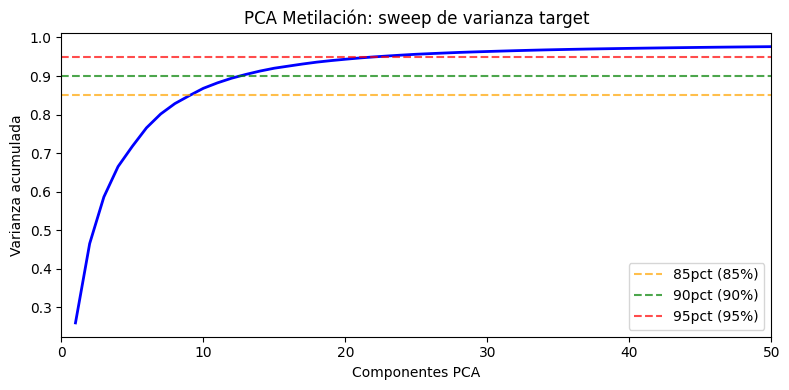

In [4]:
print("=" * 70)
print("SECCIÓN 3: PCA Sweep — exploración de varianza")
print("=" * 70)

# Exploración global para entender la estructura
X_all = df_pre[cpg_cols].values.astype(np.float32)
imp_check = SimpleImputer(strategy='median')
X_clean = imp_check.fit_transform(X_all)
sc_check = StandardScaler()
X_scaled = sc_check.fit_transform(X_clean)
pca_full = PCA(n_components=min(50, X_scaled.shape[1]), random_state=SEED)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
print(f"Varianza explicada por componente:")
for target, pct in PCA_VARIANTS.items():
    n_comp = np.searchsorted(cumvar, pct) + 1
    print(f"  {target} ({pct*100:.0f}%): {n_comp} componentes")

# Correlación de primeros PCs con study_part (diagnóstico de dominio)
X_pca = pca_full.transform(X_scaled)
sp_vals = df_pre['study_part'].values
valid_sp = ~pd.isna(sp_vals)
print(f"\n--- Correlación PC vs study_part (ANOVA eta²) ---")
for pc_i in range(min(10, X_pca.shape[1])):
    pc_vals = X_pca[valid_sp, pc_i]
    sp_valid = sp_vals[valid_sp]
    groups = [pc_vals[sp_valid == sp] for sp in np.unique(sp_valid)]
    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        F, p = stats.f_oneway(*groups)
        ss_between = sum(len(g) * (g.mean() - pc_vals.mean())**2 for g in groups)
        ss_total = np.sum((pc_vals - pc_vals.mean())**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        pdl_rho, _ = stats.spearmanr(X_pca[valid_sp, pc_i], df_pre.loc[valid_sp, 'pdl_norm'].values)
        tag = '🔴' if eta2 > 0.2 else '🟡' if eta2 > 0.05 else '✅'
        print(f"  PC{pc_i+1:>2}: var={pca_full.explained_variance_ratio_[pc_i]*100:5.1f}%  "
              f"η²(sp)={eta2:.3f} {tag}  ρ(PDL)={pdl_rho:+.3f}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
colors = {'85pct': 'orange', '90pct': 'green', '95pct': 'red'}
for target, pct in PCA_VARIANTS.items():
    ax.axhline(y=pct, color=colors[target], linestyle='--', alpha=0.7, label=f'{target} ({pct*100:.0f}%)')
ax.set_xlabel('Componentes PCA'); ax.set_ylabel('Varianza acumulada')
ax.set_title('PCA Metilación: sweep de varianza target')
ax.legend(); ax.set_xlim(0, 50)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "plots" / "pca_variance_sweep.png", dpi=150)
plt.show()

del X_all, X_clean, X_scaled, X_pca, pca_full, sc_check, imp_check

## Sección 4: Modelo v2 — MetEncoder austero + CORAL

In [5]:
print("=" * 70)
print("SECCIÓN 4: Modelo v2")
print("=" * 70)

class MetEncoderV2(nn.Module):
    """
    PCA+MLP encoder v2: más austero, con proyección a 256 para fusión.
    
    PCA(N) → Dropout(0.6) → Linear(128) → ReLU → Dropout(0.4)
           → Linear(128) = z_internal
           → Linear(256) = z_met (para fusión, sin activación)
           → Linear(32) → ReLU → Linear(1) = PDL_hat (desde z_internal)
    """
    def __init__(self, input_dim, hidden_dim=128, z_dim=128,
                 fusion_dim=256, pdl_head_dim=32,
                 dropout_input=0.6, dropout_hidden=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Dropout(dropout_input),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_hidden),
            nn.Linear(hidden_dim, z_dim),
        )
        # Proyección lineal a 256 para compatibilidad con fusión
        self.fusion_proj = nn.Linear(z_dim, fusion_dim)
        # PDL head desde z_internal (128), no desde fusion_proj (256)
        self.pdl_head = nn.Sequential(
            nn.Linear(z_dim, pdl_head_dim),
            nn.ReLU(),
            nn.Linear(pdl_head_dim, 1),
        )

    def forward(self, x):
        z_internal = self.encoder(x)
        pdl_hat = self.pdl_head(z_internal).squeeze(-1)
        return z_internal, pdl_hat

    def encode_for_fusion(self, x):
        """Produce z_met (256-dim) para fusión multimodal."""
        with torch.no_grad():
            z_internal = self.encoder(x)
            return self.fusion_proj(z_internal)

    def encode(self, x):
        """Produce z_internal (128-dim) para diagnóstico."""
        with torch.no_grad():
            return self.encoder(x)

# Test
model_test = MetEncoderV2(input_dim=10, hidden_dim=HP['hidden_dim'],
                          z_dim=HP['z_dim'], fusion_dim=HP['fusion_dim'],
                          pdl_head_dim=HP['pdl_head_dim'])
x_test = torch.randn(4, 10)
z_test, p_test = model_test(x_test)
z_fus = model_test.encode_for_fusion(x_test)
n_params = sum(p.numel() for p in model_test.parameters())
print(f"z_internal: {z_test.shape}, PDL_hat: {p_test.shape}, z_fusion: {z_fus.shape}")
print(f"Parámetros: {n_params:,}")
print(f"\n{model_test}")
del model_test, x_test, z_test, p_test, z_fus

SECCIÓN 4: Modelo v2
z_internal: torch.Size([4, 128]), PDL_hat: torch.Size([4]), z_fusion: torch.Size([4, 256])
Parámetros: 55,105

MetEncoderV2(
  (encoder): Sequential(
    (0): Dropout(p=0.6, inplace=False)
    (1): Linear(in_features=10, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
  (fusion_proj): Linear(in_features=128, out_features=256, bias=True)
  (pdl_head): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Sección 5: Loss Functions + CORAL

In [6]:
print("=" * 70)
print("SECCIÓN 5: Loss Functions")
print("=" * 70)

class RankingLoss(nn.Module):
    def __init__(self, margin=0.1):
        super().__init__()
        self.margin = margin

    def forward(self, pdl_hat, pdl_true):
        n = len(pdl_hat)
        if n < 2:
            return torch.tensor(0.0, device=pdl_hat.device)
        n_pairs = min(n * 2, 256)
        idx_a = torch.randint(0, n, (n_pairs,), device=pdl_hat.device)
        idx_b = torch.randint(0, n, (n_pairs,), device=pdl_hat.device)
        diff_true = pdl_true[idx_a] - pdl_true[idx_b]
        valid = diff_true.abs() > 0.01
        if valid.sum() < 2:
            return torch.tensor(0.0, device=pdl_hat.device)
        idx_a, idx_b = idx_a[valid], idx_b[valid]
        diff_true = diff_true[valid]
        diff_hat = pdl_hat[idx_a] - pdl_hat[idx_b]
        target = torch.sign(diff_true)
        loss = torch.clamp(self.margin - target * diff_hat, min=0)
        return loss.mean()


def coral_loss(z_source, z_target):
    """
    CORAL: penaliza diferencia de covarianzas entre dominios.
    Ref: Sun & Saenko, AAAI 2016.
    """
    if len(z_source) < 2 or len(z_target) < 2:
        return torch.tensor(0.0, device=z_source.device)
    d = z_source.shape[1]
    # Covariance matrices
    cs = torch.cov(z_source.T)
    ct = torch.cov(z_target.T)
    # Frobenius norm squared, normalized by d^2
    loss = torch.sum((cs - ct) ** 2) / (4 * d * d)
    return loss


class CombinedLossV2(nn.Module):
    def __init__(self, lambda_rank=0.5, rank_margin=0.1, lambda_coral=0.0):
        super().__init__()
        self.mse = nn.MSELoss()
        self.ranking = RankingLoss(margin=rank_margin)
        self.lambda_rank = lambda_rank
        self.lambda_coral = lambda_coral

    def forward(self, pdl_hat, pdl_true, z=None, study_parts=None):
        l_mse = self.mse(pdl_hat, pdl_true)
        l_rank = self.ranking(pdl_hat, pdl_true)
        total = l_mse + self.lambda_rank * l_rank

        l_coral = torch.tensor(0.0, device=pdl_hat.device)
        if self.lambda_coral > 0 and z is not None and study_parts is not None:
            unique_sp = study_parts.unique()
            if len(unique_sp) >= 2:
                # CORAL between all pairs of study_parts
                coral_sum = torch.tensor(0.0, device=z.device)
                n_pairs = 0
                for i in range(len(unique_sp)):
                    for j in range(i+1, len(unique_sp)):
                        mask_i = study_parts == unique_sp[i]
                        mask_j = study_parts == unique_sp[j]
                        if mask_i.sum() >= 2 and mask_j.sum() >= 2:
                            coral_sum += coral_loss(z[mask_i], z[mask_j])
                            n_pairs += 1
                if n_pairs > 0:
                    l_coral = coral_sum / n_pairs
                    total += self.lambda_coral * l_coral

        return total, l_mse.item(), l_rank.item(), l_coral.item()

print(f"Loss v2 definida ✓")
print(f"  λ_rank = {HP['lambda_rank']}, margin = {HP['rank_margin']}")
print(f"  λ_coral = {HP['lambda_coral']} {'(DESACTIVADO)' if HP['lambda_coral'] == 0 else '(ACTIVO)'}")

SECCIÓN 5: Loss Functions
Loss v2 definida ✓
  λ_rank = 0.5, margin = 0.1
  λ_coral = 0.0 (DESACTIVADO)


## Sección 6: Dataset y DataLoaders

In [7]:
print("=" * 70)
print("SECCIÓN 6: Dataset y DataLoader")
print("=" * 70)

class MetDatasetV2(Dataset):
    """Dataset con study_part para CORAL."""

    def __init__(self, df, cpg_cols, pca_variance=0.85, pca=None, scaler=None,
                 imputer=None, fit_preprocessing=False):
        self.pdl = torch.tensor(df['pdl_norm'].values, dtype=torch.float32)
        self.sample_ids = df['sample_id'].values if 'sample_id' in df.columns else np.arange(len(df))

        # study_part as tensor for CORAL (encode as int)
        if 'study_part' in df.columns:
            sp = df['study_part'].fillna(-1).values.astype(np.int64)
            self.study_part = torch.tensor(sp, dtype=torch.long)
        else:
            self.study_part = torch.full((len(df),), -1, dtype=torch.long)

        self.cell_line = df['cell_line'].values if 'cell_line' in df.columns else None

        X = df[cpg_cols].values.astype(np.float32)

        if fit_preprocessing:
            self.imputer = SimpleImputer(strategy='median')
            X = self.imputer.fit_transform(X)
            self.scaler = StandardScaler()
            X = self.scaler.fit_transform(X)
            self.pca = PCA(n_components=pca_variance, random_state=SEED)
            X = self.pca.fit_transform(X)
        else:
            self.imputer = imputer
            self.scaler = scaler
            self.pca = pca
            if imputer is not None: X = imputer.transform(X)
            if scaler is not None: X = scaler.transform(X)
            if pca is not None: X = pca.transform(X)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.input_dim = self.X.shape[1]

    def __len__(self):
        return len(self.pdl)

    def __getitem__(self, idx):
        return self.X[idx], self.pdl[idx], self.study_part[idx]


def build_met_loaders_v2(df, cpg_cols, fold_val, batch_size, pca_variance, stage="pretrain"):
    train_mask = df['fold'] != fold_val
    val_mask   = df['fold'] == fold_val
    df_train = df[train_mask].reset_index(drop=True)
    df_val   = df[val_mask].reset_index(drop=True)

    ds_train = MetDatasetV2(df_train, cpg_cols, pca_variance=pca_variance,
                            fit_preprocessing=True)
    ds_val   = MetDatasetV2(df_val, cpg_cols,
                            pca=ds_train.pca, scaler=ds_train.scaler,
                            imputer=ds_train.imputer)

    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                              drop_last=len(ds_train) > batch_size)
    loader_val   = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    print(f"  [{stage}] Fold {int(fold_val)}: train={len(ds_train)}, val={len(ds_val)}, "
          f"PCA({pca_variance*100:.0f}%)={ds_train.input_dim} dims")

    return loader_train, loader_val, ds_train.pca, ds_train.scaler, ds_train.imputer

print("Dataset y DataLoader v2 definidos ✓")

SECCIÓN 6: Dataset y DataLoader
Dataset y DataLoader v2 definidos ✓


## Sección 7: Training Infrastructure

In [8]:
print("=" * 70)
print("SECCIÓN 7: Training Infrastructure")
print("=" * 70)

def train_one_epoch_v2(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_mse, total_rank, total_coral = 0, 0, 0, 0
    all_hat, all_true = [], []
    for X, pdl, sp in loader:
        X, pdl, sp = X.to(device), pdl.to(device), sp.to(device)
        z, pdl_hat = model(X)
        loss, mse_v, rank_v, coral_v = criterion(pdl_hat, pdl, z, sp)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X)
        total_mse += mse_v * len(X)
        total_rank += rank_v * len(X)
        total_coral += coral_v * len(X)
        all_hat.extend(pdl_hat.detach().cpu().numpy())
        all_true.extend(pdl.cpu().numpy())
    n = len(all_hat)
    rho, _ = stats.spearmanr(all_hat, all_true)
    return {'loss': total_loss/n, 'mse': total_mse/n, 'rank': total_rank/n,
            'coral': total_coral/n, 'spearman': rho}


@torch.no_grad()
def eval_one_epoch_v2(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_hat, all_true, all_z = [], [], []
    for X, pdl, sp in loader:
        X, pdl, sp = X.to(device), pdl.to(device), sp.to(device)
        z, pdl_hat = model(X)
        loss, _, _, _ = criterion(pdl_hat, pdl, z, sp)
        total_loss += loss.item() * len(X)
        all_hat.extend(pdl_hat.cpu().numpy())
        all_true.extend(pdl.cpu().numpy())
        all_z.append(z.cpu().numpy())
    n = len(all_hat)
    all_hat = np.array(all_hat); all_true = np.array(all_true)
    rho, _ = stats.spearmanr(all_hat, all_true)
    mae = np.mean(np.abs(all_hat - all_true))
    ss_res = np.sum((all_hat - all_true)**2)
    ss_tot = np.sum((all_true - all_true.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    return {'loss': total_loss/n, 'spearman': rho, 'mae': mae, 'r2': r2,
            'pdl_hat': all_hat, 'pdl_true': all_true,
            'z': np.concatenate(all_z, axis=0)}


def train_model_v2(model, train_loader, val_loader, criterion, optimizer,
                   scheduler, device, epochs, patience, stage_name="train"):
    best_rho, best_epoch, best_state, no_improve = -1, 0, None, 0
    history = {'train_spearman':[], 'val_spearman':[], 'train_loss':[], 'val_loss':[]}

    print(f"\n  [{stage_name}] Training up to {epochs} ep (patience={patience})...")
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tm = train_one_epoch_v2(model, train_loader, criterion, optimizer, device)
        vm = eval_one_epoch_v2(model, val_loader, criterion, device)
        if scheduler: scheduler.step(vm['spearman'])

        history['train_spearman'].append(tm['spearman'])
        history['val_spearman'].append(vm['spearman'])
        history['train_loss'].append(tm['loss'])
        history['val_loss'].append(vm['loss'])

        if vm['spearman'] > best_rho:
            best_rho = vm['spearman']; best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1 or no_improve == 0:
            gap = tm['spearman'] - vm['spearman']
            coral_str = f" CORAL={tm['coral']:.4f}" if tm['coral'] > 0 else ""
            print(f"    Ep {epoch:>3d} | Train ρ={tm['spearman']:.3f} Val ρ={vm['spearman']:.3f} "
                  f"Gap={gap:+.3f} | MSE={vm['loss']:.4f}{coral_str} | {time.time()-t0:.1f}s"
                  f"{'  ★' if no_improve == 0 else ''}")

        if no_improve >= patience:
            print(f"    Early stop ep {epoch} (best={best_epoch}, ρ={best_rho:.4f})")
            break

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())
    history['best_epoch'] = best_epoch
    return best_state, history

print("Training infrastructure v2 ✓")

SECCIÓN 7: Training Infrastructure
Training infrastructure v2 ✓


## Sección 8: PCA Sweep — entrenar con 85%, 90%, 95%

Se entrena el encoder v2 con cada variante de PCA para determinar el sweet spot.
Solo Stage 1 (PRETRAIN) para el sweep — el mejor pasa a Stage 2.

In [9]:
print("=" * 70)
print("SECCIÓN 8: PCA Sweep — PRETRAIN only")
print("=" * 70)

folds = sorted(df_pre['fold'].dropna().unique())
sweep_results = {}

for pca_name, pca_var in PCA_VARIANTS.items():
    print(f"\n{'#'*60}")
    print(f"  PCA VARIANT: {pca_name} ({pca_var*100:.0f}%)")
    print(f"{'#'*60}")

    fold_results = {}
    for fold_val in folds:
        fi = int(fold_val)
        print(f"\n  --- Fold {fi} ---")

        tr_ldr, vl_ldr, pca_obj, sc_obj, imp_obj = build_met_loaders_v2(
            df_pre, cpg_cols, fold_val, HP['batch_size_pretrain'], pca_var, f"PRE-{pca_name}")

        input_dim = tr_ldr.dataset.input_dim
        model = MetEncoderV2(
            input_dim=input_dim, hidden_dim=HP['hidden_dim'],
            z_dim=HP['z_dim'], fusion_dim=HP['fusion_dim'],
            pdl_head_dim=HP['pdl_head_dim'],
            dropout_input=HP['dropout_input'],
            dropout_hidden=HP['dropout_hidden']
        ).to(DEVICE)

        criterion = CombinedLossV2(HP['lambda_rank'], HP['rank_margin'], HP['lambda_coral'])
        opt = optim.AdamW(model.parameters(), lr=HP['lr_pretrain'], weight_decay=HP['wd_pretrain'])
        sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=10)

        best_state, hist = train_model_v2(model, tr_ldr, vl_ldr, criterion, opt, sched,
                                          DEVICE, HP['epochs_pretrain'], HP['patience_pretrain'],
                                          f"PRE F{fi}")
        model.load_state_dict(best_state)
        ev = eval_one_epoch_v2(model, vl_ldr, criterion, DEVICE)

        fold_results[fi] = {
            'spearman': ev['spearman'], 'mae': ev['mae'], 'r2': ev['r2'],
            'input_dim': input_dim, 'best_epoch': hist['best_epoch'],
            'model_state': best_state, 'pca': pca_obj, 'scaler': sc_obj, 'imputer': imp_obj,
            'history': hist,
        }
        print(f"  → Fold {fi}: ρ={ev['spearman']:.4f}, MAE={ev['mae']:.4f}, dims={input_dim}")

    rhos = [fold_results[fi]['spearman'] for fi in sorted(fold_results)]
    sweep_results[pca_name] = {
        'pca_var': pca_var,
        'mean_rho': np.mean(rhos), 'std_rho': np.std(rhos),
        'worst_rho': np.min(rhos), 'by_fold': fold_results,
    }
    print(f"\n  {pca_name} RESUMEN: ρ={np.mean(rhos):.4f}±{np.std(rhos):.4f}, worst={np.min(rhos):.4f}")

# Summary table
print(f"\n{'='*70}")
print(f"  PCA SWEEP SUMMARY (PRETRAIN only)")
print(f"{'='*70}")
print(f"{'Variant':<10}{'Dims':<8}{'ρ mean':>8}{'ρ worst':>10}{'F0':>8}{'F1':>8}{'F2':>8}")
print("-" * 60)
for pca_name, r in sweep_results.items():
    dims = r['by_fold'][0]['input_dim']
    f0 = r['by_fold'][0]['spearman']
    f1 = r['by_fold'][1]['spearman']
    f2 = r['by_fold'][2]['spearman']
    print(f"{pca_name:<10}{dims:<8}{r['mean_rho']:>8.4f}{r['worst_rho']:>10.4f}{f0:>8.4f}{f1:>8.4f}{f2:>8.4f}")
print(f"\nv1 ref:   23      {V1_RESULTS['mean']:>8.4f}{V1_RESULTS['worst']:>10.4f}"
      f"{V1_RESULTS['by_fold'][0]:>8.4f}{V1_RESULTS['by_fold'][1]:>8.4f}{V1_RESULTS['by_fold'][2]:>8.4f}")
print(f"PCA+EN:   8       {BASELINE_EN['mean']:>8.4f}{BASELINE_EN['worst']:>10.4f}")

SECCIÓN 8: PCA Sweep — PRETRAIN only

############################################################
  PCA VARIANT: 85pct (85%)
############################################################

  --- Fold 0 ---
  [PRE-85pct] Fold 0: train=336, val=143, PCA(85%)=9 dims

  [PRE F0] Training up to 200 ep (patience=25)...
    Ep   1 | Train ρ=0.099 Val ρ=-0.552 Gap=+0.651 | MSE=0.5827 | 4.9s  ★
    Ep   3 | Train ρ=-0.047 Val ρ=-0.446 Gap=+0.399 | MSE=0.1485 | 0.2s  ★
    Ep   4 | Train ρ=0.245 Val ρ=0.535 Gap=-0.290 | MSE=0.1507 | 0.2s  ★
    Ep   8 | Train ρ=0.247 Val ρ=0.589 Gap=-0.342 | MSE=0.1331 | 0.1s  ★
    Ep  10 | Train ρ=0.460 Val ρ=0.088 Gap=+0.373 | MSE=0.1313 | 0.1s
    Ep  14 | Train ρ=0.444 Val ρ=0.611 Gap=-0.166 | MSE=0.1225 | 0.1s  ★
    Ep  15 | Train ρ=0.451 Val ρ=0.660 Gap=-0.209 | MSE=0.1180 | 0.1s  ★
    Ep  20 | Train ρ=0.487 Val ρ=0.678 Gap=-0.190 | MSE=0.1051 | 0.1s  ★
    Ep  27 | Train ρ=0.490 Val ρ=0.685 Gap=-0.195 | MSE=0.1101 | 0.1s  ★
    Ep  28 | Train ρ=0.471 Va

## Sección 9: Selección del mejor PCA + Stage 2 FINETUNE

In [10]:
print("=" * 70)
print("SECCIÓN 9: Mejor PCA → Stage 2 FINETUNE")
print("=" * 70)

# Seleccionar variante PCA con mejor worst fold (priorizar robustez sobre promedio)
best_pca = max(sweep_results.keys(), key=lambda k: sweep_results[k]['worst_rho'])
print(f"Mejor PCA por worst fold: {best_pca} (worst={sweep_results[best_pca]['worst_rho']:.4f})")

# Si empatan en worst, desempatar por mean
candidates = [k for k in sweep_results if
              sweep_results[k]['worst_rho'] >= sweep_results[best_pca]['worst_rho'] - 0.02]
if len(candidates) > 1:
    best_pca = max(candidates, key=lambda k: sweep_results[k]['mean_rho'])
    print(f"Desempate por mean → {best_pca} (mean={sweep_results[best_pca]['mean_rho']:.4f})")

best_pca_var = sweep_results[best_pca]['pca_var']
print(f"\nUsando PCA {best_pca} ({best_pca_var*100:.0f}%) para FINETUNE")

# Stage 2: FINETUNE con el mejor PCA
all_results = {}
for fold_val in folds:
    fi = int(fold_val)
    print(f"\n{'='*50}")
    print(f"  FOLD {fi} — FINETUNE (PCA={best_pca})")
    print(f"{'='*50}")

    # Recuperar modelo y preprocesamiento de Stage 1
    pre_res = sweep_results[best_pca]['by_fold'][fi]
    pre_state = pre_res['model_state']
    pca_obj = pre_res['pca']
    sc_obj = pre_res['scaler']
    imp_obj = pre_res['imputer']
    input_dim = pre_res['input_dim']

    # Reconstruir modelo con pesos de PRETRAIN
    model = MetEncoderV2(
        input_dim=input_dim, hidden_dim=HP['hidden_dim'],
        z_dim=HP['z_dim'], fusion_dim=HP['fusion_dim'],
        pdl_head_dim=HP['pdl_head_dim'],
        dropout_input=HP['dropout_input'],
        dropout_hidden=HP['dropout_hidden']
    ).to(DEVICE)
    model.load_state_dict(pre_state)

    # FINETUNE loaders (using PRETRAIN PCA/scaler)
    ft_train = df_ft[df_ft['fold'] != fold_val].reset_index(drop=True)
    ft_val = df_ft[df_ft['fold'] == fold_val].reset_index(drop=True)
    print(f"  FINETUNE: train={len(ft_train)}, val={len(ft_val)}")

    if len(ft_train) < 10 or len(ft_val) < 5:
        print(f"  ⚠️ Insuficientes muestras FT. Usando PRETRAIN result.")
        # Evaluate on FT val with pretrain model
        ds_ft_vl = MetDatasetV2(ft_val, cpg_cols, pca=pca_obj, scaler=sc_obj, imputer=imp_obj)
        ldr_ft_vl = DataLoader(ds_ft_vl, batch_size=32, shuffle=False)
        criterion = CombinedLossV2(HP['lambda_rank'], HP['rank_margin'], 0.0)
        ft_eval = eval_one_epoch_v2(model, ldr_ft_vl, criterion, DEVICE)
        best_state = pre_state
        hist_ft = None
    else:
        ds_ft_tr = MetDatasetV2(ft_train, cpg_cols, pca=pca_obj, scaler=sc_obj, imputer=imp_obj)
        ds_ft_vl = MetDatasetV2(ft_val, cpg_cols, pca=pca_obj, scaler=sc_obj, imputer=imp_obj)
        ldr_ft_tr = DataLoader(ds_ft_tr, batch_size=min(HP['batch_size_finetune'], len(ds_ft_tr)),
                               shuffle=True)
        ldr_ft_vl = DataLoader(ds_ft_vl, batch_size=32, shuffle=False)

        # No CORAL in FINETUNE (too few samples per study_part)
        criterion = CombinedLossV2(HP['lambda_rank'], HP['rank_margin'], 0.0)
        opt_ft = optim.AdamW(model.parameters(), lr=HP['lr_finetune'], weight_decay=HP['wd_finetune'])
        sched_ft = optim.lr_scheduler.ReduceLROnPlateau(opt_ft, mode='max', factor=0.5, patience=8)

        best_state, hist_ft = train_model_v2(model, ldr_ft_tr, ldr_ft_vl, criterion, opt_ft, sched_ft,
                                              DEVICE, HP['epochs_finetune'], HP['patience_finetune'],
                                              f"FT F{fi}")
        model.load_state_dict(best_state)
        ft_eval = eval_one_epoch_v2(model, ldr_ft_vl, criterion, DEVICE)

    print(f"  Stage 2: ρ={ft_eval['spearman']:.4f}, MAE={ft_eval['mae']:.4f}, R²={ft_eval['r2']:.4f}")

    # Overfitting gap
    if hist_ft and 'best_epoch' in hist_ft:
        be = min(hist_ft['best_epoch']-1, len(hist_ft['train_spearman'])-1)
        train_rho = hist_ft['train_spearman'][be]
    else:
        be = min(pre_res['best_epoch']-1, len(pre_res['history']['train_spearman'])-1)
        train_rho = pre_res['history']['train_spearman'][be]
    gap = train_rho - ft_eval['spearman']
    print(f"  Gap: {gap:+.3f} (train={train_rho:.3f}, val={ft_eval['spearman']:.3f})")

    all_results[fi] = {
        'pre_spearman': pre_res['spearman'], 'ft_spearman': ft_eval['spearman'],
        'ft_mae': ft_eval['mae'], 'ft_r2': ft_eval['r2'], 'overfitting_gap': gap,
        'train_spearman': train_rho,
        'z_val': ft_eval['z'], 'pdl_hat_val': ft_eval['pdl_hat'], 'pdl_true_val': ft_eval['pdl_true'],
        'history_pre': pre_res['history'], 'history_ft': hist_ft, 'model_state': best_state,
        'pca': pca_obj, 'scaler': sc_obj, 'imputer': imp_obj,
        'input_dim': input_dim, 'pca_variant': best_pca,
    }

    # Save model
    torch.save({'model_state_dict': best_state, 'hp': HP, 'fold': fi,
                'input_dim': input_dim, 'pca_variant': best_pca,
                'metrics': {'pre_spearman': pre_res['spearman'],
                            'ft_spearman': ft_eval['spearman'],
                            'ft_mae': ft_eval['mae'], 'ft_r2': ft_eval['r2']}},
               OUTPUT_DIR / f"fold{fi}_model.pt")
    print(f"  Modelo guardado: fold{fi}_model.pt")

SECCIÓN 9: Mejor PCA → Stage 2 FINETUNE
Mejor PCA por worst fold: 90pct (worst=0.4485)

Usando PCA 90pct (90%) para FINETUNE

  FOLD 0 — FINETUNE (PCA=90pct)
  FINETUNE: train=78, val=40

  [FT F0] Training up to 150 ep (patience=15)...
    Ep   1 | Train ρ=0.297 Val ρ=0.934 Gap=-0.636 | MSE=0.2137 | 2.1s  ★
    Ep   3 | Train ρ=0.293 Val ρ=0.951 Gap=-0.657 | MSE=0.2072 | 0.1s  ★
    Ep   4 | Train ρ=0.378 Val ρ=0.959 Gap=-0.581 | MSE=0.1978 | 0.0s  ★
    Ep   5 | Train ρ=0.346 Val ρ=0.960 Gap=-0.614 | MSE=0.1943 | 0.0s  ★
    Ep   6 | Train ρ=0.483 Val ρ=0.962 Gap=-0.479 | MSE=0.1919 | 0.0s  ★
    Ep   7 | Train ρ=0.446 Val ρ=0.963 Gap=-0.518 | MSE=0.1883 | 0.1s  ★
    Ep   8 | Train ρ=0.160 Val ρ=0.965 Gap=-0.805 | MSE=0.1848 | 0.1s  ★
    Ep  10 | Train ρ=0.370 Val ρ=0.958 Gap=-0.589 | MSE=0.1892 | 0.0s
    Ep  20 | Train ρ=0.329 Val ρ=0.938 Gap=-0.609 | MSE=0.1994 | 0.0s
    Early stop ep 23 (best=8, ρ=0.9649)
  Stage 2: ρ=0.9649, MAE=0.3308, R²=-0.9668
  Gap: -0.805 (train=0.160, 

## Sección 10: Resumen de métricas

In [11]:
print("=" * 70)
print("SECCIÓN 10: Resumen de Métricas v2")
print("=" * 70)

rhos = [all_results[fi]['ft_spearman'] for fi in sorted(all_results)]
mean_rho = np.mean(rhos)
std_rho = np.std(rhos)
worst_rho = np.min(rhos)
worst_fold_id = sorted(all_results)[np.argmin(rhos)]
en_mean = BASELINE_EN['mean']

print(f"\n{'Fold':<6}{'PRE ρ':>8}{'FT ρ':>8}{'MAE':>8}{'R²':>8}{'Gap':>8}{'N val':>8}")
print("-" * 56)
for fi in sorted(all_results):
    r = all_results[fi]
    nval = len(r['pdl_true_val'])
    print(f"  {fi:<4}{r['pre_spearman']:>8.4f}{r['ft_spearman']:>8.4f}"
          f"{r['ft_mae']:>8.4f}{r['ft_r2']:>8.4f}{r['overfitting_gap']:>+8.3f}{nval:>8}")
print(f"\n  Promedio: {mean_rho:.4f} ± {std_rho:.4f}")
print(f"  Worst:    {worst_rho:.4f} (Fold {worst_fold_id})")

# vs targets
print(f"\n--- vs Targets ---")
for name, (val, target) in [
    ('Spearman ≥ aspiracional', (mean_rho, TARGETS['spearman_aspiracional'])),
    ('Spearman ≥ piso', (mean_rho, TARGETS['spearman_piso'])),
    ('Worst fold ≥ piso', (worst_rho, TARGETS['worst_fold_piso'])),
]:
    status = '✅' if val >= target else '❌'
    print(f"  {status} {name}: {val:.4f} vs {target:.4f}")

# vs v1 and baseline
print(f"\n--- vs v1 ---")
print(f"  Promedio: {mean_rho:.4f} vs {V1_RESULTS['mean']:.4f} ({mean_rho/V1_RESULTS['mean']*100:.1f}%)")
print(f"  Worst:    {worst_rho:.4f} vs {V1_RESULTS['worst']:.4f} ({worst_rho/V1_RESULTS['worst']*100:.1f}%)")
for fi in sorted(all_results):
    v1_fi = V1_RESULTS['by_fold'][fi]
    v2_fi = all_results[fi]['ft_spearman']
    delta = v2_fi - v1_fi
    print(f"  Fold {fi}: {v2_fi:.4f} vs {v1_fi:.4f} (Δ={delta:+.4f})")

print(f"\n--- vs PCA+EN baseline ---")
print(f"  Promedio: {mean_rho:.4f} / {en_mean:.4f} = {mean_rho/en_mean*100:.1f}%")
print(f"  Worst:    {worst_rho:.4f} / {BASELINE_EN['worst']:.4f} = {worst_rho/BASELINE_EN['worst']*100:.1f}%")

SECCIÓN 10: Resumen de Métricas v2

Fold     PRE ρ    FT ρ     MAE      R²     Gap   N val
--------------------------------------------------------
  0     0.9214  0.9649  0.3308 -0.9668  -0.805      40
  1     0.7829  0.9039  0.2359 -0.0757  -0.384      49
  2     0.4485  0.7257  0.2394  0.0232  -0.265      29

  Promedio: 0.8648 ± 0.1015
  Worst:    0.7257 (Fold 2)

--- vs Targets ---
  ✅ Spearman ≥ aspiracional: 0.8648 vs 0.6950
  ✅ Spearman ≥ piso: 0.8648 vs 0.5500
  ✅ Worst fold ≥ piso: 0.7257 vs 0.4500

--- vs v1 ---
  Promedio: 0.8648 vs 0.5582 (154.9%)
  Worst:    0.7257 vs 0.3035 (239.1%)
  Fold 0: 0.9649 vs 0.9710 (Δ=-0.0061)
  Fold 1: 0.9039 vs 0.4000 (Δ=+0.5039)
  Fold 2: 0.7257 vs 0.3035 (Δ=+0.4222)

--- vs PCA+EN baseline ---
  Promedio: 0.8648 / 0.7720 = 112.0%
  Worst:    0.7257 / 0.6100 = 119.0%


## Sección 11: Batch Probe

In [12]:
print("=" * 70)
print("SECCIÓN 11: Batch Probe — study_part")
print("=" * 70)

batch_results = {}
for fi in sorted(all_results):
    r = all_results[fi]
    z_val = r['z_val']

    df_source = df_ft if (df_ft['fold'] == fi).sum() >= 5 else df_pre
    df_val = df_source[df_source['fold'] == fi].reset_index(drop=True)

    if 'study_part' not in df_val.columns or df_val['study_part'].nunique() < 2:
        print(f"  Fold {fi}: study_part no disponible o constante.")
        batch_results[fi] = {'auc_z': None, 'auc_baseline': None, 'delta': None}
        continue

    n_use = min(len(z_val), len(df_val))
    sp = df_val['study_part'].values[:n_use]
    pdl_v = df_val['pdl_norm'].values[:n_use]
    cl_v = df_val['cell_line'].values[:n_use]
    z_u = z_val[:n_use]

    valid = ~pd.isna(sp) & ~pd.isna(pdl_v)
    sp, pdl_v, cl_v, z_u = sp[valid], pdl_v[valid], cl_v[valid], z_u[valid]
    if len(np.unique(sp)) < 2:
        batch_results[fi] = {'auc_z': None, 'auc_baseline': None, 'delta': None}
        continue

    le = LabelEncoder(); cl_enc = le.fit_transform(cl_v).reshape(-1, 1)

    # AUC from z_met
    try:
        sc_z = StandardScaler(); z_sc = sc_z.fit_transform(z_u)
        clf_z = LogisticRegression(max_iter=500, C=1.0)
        clf_z.fit(z_sc, sp)
        proba_z = clf_z.predict_proba(z_sc)
        if len(np.unique(sp)) == 2:
            auc_z = roc_auc_score(sp, proba_z[:, 1])
        else:
            auc_z = roc_auc_score(sp, proba_z, multi_class='ovr', average='macro')
    except Exception as e:
        print(f"  Fold {fi}: Error AUC z: {e}"); auc_z = 0.5

    # AUC baseline: PDL + cell_line
    try:
        X_b = np.column_stack([pdl_v.reshape(-1,1), cl_enc])
        sc_b = StandardScaler(); X_bs = sc_b.fit_transform(X_b)
        clf_b = LogisticRegression(max_iter=500, C=1.0)
        clf_b.fit(X_bs, sp)
        proba_b = clf_b.predict_proba(X_bs)
        if len(np.unique(sp)) == 2:
            auc_b = roc_auc_score(sp, proba_b[:, 1])
        else:
            auc_b = roc_auc_score(sp, proba_b, multi_class='ovr', average='macro')
    except Exception as e:
        print(f"  Fold {fi}: Error AUC baseline: {e}"); auc_b = 0.5

    delta = auc_z - auc_b
    batch_results[fi] = {'auc_z': auc_z, 'auc_baseline': auc_b, 'delta': delta}
    v1_delta = V1_RESULTS['batch_delta'].get(fi, None)
    v1_str = f" (v1: +{v1_delta:.3f})" if v1_delta else ""
    print(f"  Fold {fi}: AUC(z_met)={auc_z:.3f}, AUC(PDL+cl)={auc_b:.3f}, ΔAUC={delta:+.3f}{v1_str}")

deltas = [v['delta'] for v in batch_results.values() if v['delta'] is not None]
if deltas:
    print(f"\n  ΔAUC promedio: {np.mean(deltas):+.3f}, máximo: {np.max(deltas):+.3f}")
    print(f"  v1 promedio: +0.321")
    if np.mean(deltas) > 0.10:
        print(f"  🔴 Contaminación alta (>{TARGETS['delta_auc_condicional']:.2f})")
    else:
        print(f"  ✅ Contaminación aceptable")

SECCIÓN 11: Batch Probe — study_part
  Fold 0: AUC(z_met)=1.000, AUC(PDL+cl)=0.711, ΔAUC=+0.289 (v1: +0.289)
  Fold 1: AUC(z_met)=0.980, AUC(PDL+cl)=0.787, ΔAUC=+0.193 (v1: +0.212)
  Fold 2: AUC(z_met)=1.000, AUC(PDL+cl)=0.538, ΔAUC=+0.462 (v1: +0.462)

  ΔAUC promedio: +0.314, máximo: +0.462
  v1 promedio: +0.321
  🔴 Contaminación alta (>0.10)


## Sección 12: Plots diagnósticos

SECCIÓN 12: Plots


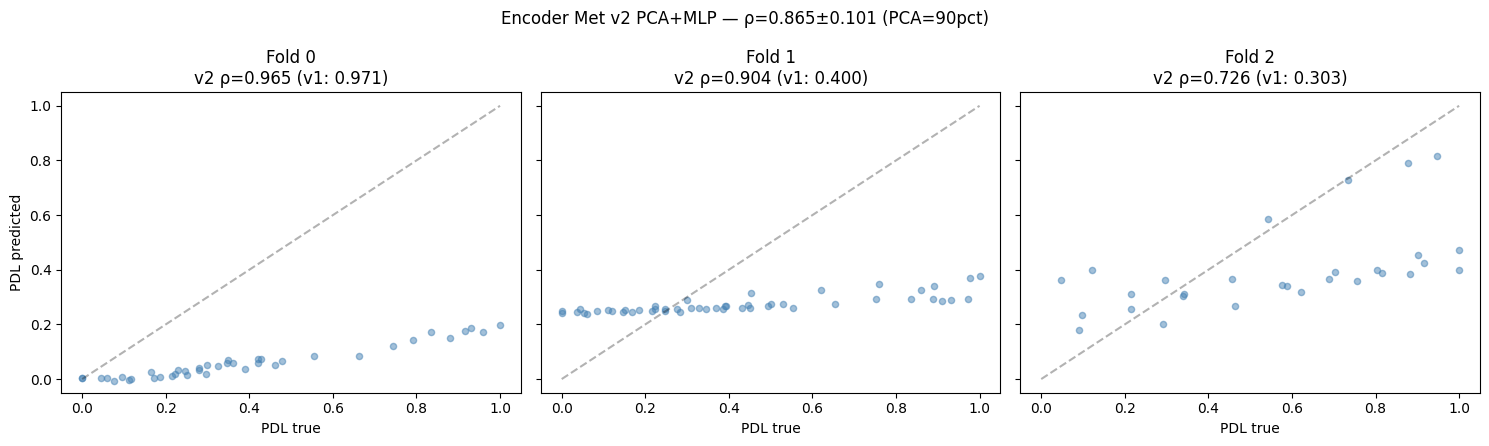

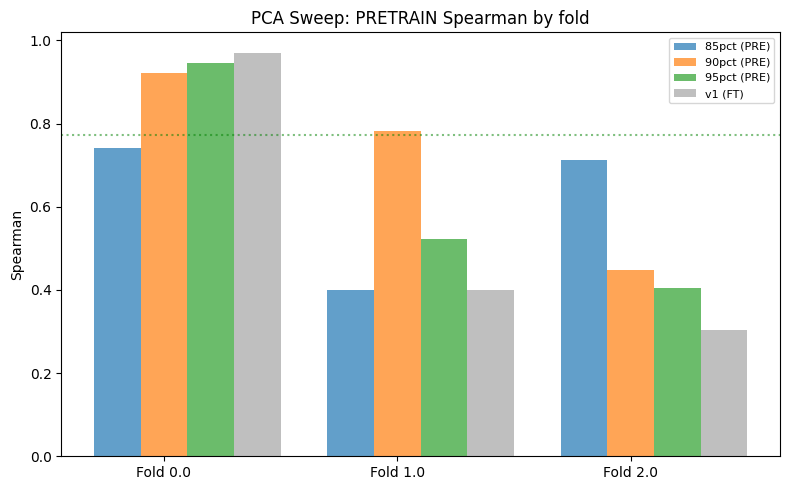

  ✓ Plots guardados


In [13]:
print("=" * 70)
print("SECCIÓN 12: Plots")
print("=" * 70)

# 12a: Scatter PDL (v2 vs v1)
fig, axes = plt.subplots(1, len(folds), figsize=(5*len(folds), 4.5), sharey=True, squeeze=False)
for i, fi in enumerate(sorted(all_results)):
    ax = axes[0][i]; r = all_results[fi]
    ax.scatter(r['pdl_true_val'], r['pdl_hat_val'], alpha=0.5, s=20, c='steelblue')
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    v1_rho = V1_RESULTS['by_fold'][fi]
    ax.set_xlabel('PDL true')
    ax.set_title(f"Fold {fi}\nv2 ρ={r['ft_spearman']:.3f} (v1: {v1_rho:.3f})")
    if i==0: ax.set_ylabel('PDL predicted')
    ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
fig.suptitle(f"Encoder Met v2 PCA+MLP — ρ={mean_rho:.3f}±{std_rho:.3f} (PCA={best_pca})", fontsize=12)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots" / "scatter_pdl_met_v2.png", dpi=150)
plt.show()

# 12b: PCA sweep comparison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
x_pos = np.arange(len(folds))
width = 0.2
for j, (pca_name, r) in enumerate(sweep_results.items()):
    rhos_sweep = [r['by_fold'][fi]['spearman'] for fi in sorted(r['by_fold'])]
    ax.bar(x_pos + j*width, rhos_sweep, width, label=f"{pca_name} (PRE)", alpha=0.7)
# Add v1 reference
v1_rhos = [V1_RESULTS['by_fold'][fi] for fi in sorted(V1_RESULTS['by_fold'])]
ax.bar(x_pos + len(PCA_VARIANTS)*width, v1_rhos, width, label='v1 (FT)', alpha=0.5, color='gray')
ax.set_xticks(x_pos + width); ax.set_xticklabels([f'Fold {fi}' for fi in sorted(folds)])
ax.set_ylabel('Spearman'); ax.set_title('PCA Sweep: PRETRAIN Spearman by fold')
ax.legend(fontsize=8); ax.axhline(y=0.772, color='green', ls=':', alpha=0.5, label='PCA+EN')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "plots" / "pca_sweep_comparison.png", dpi=150)
plt.show()
print("  ✓ Plots guardados")

## Sección 13: Correlación con relojes epigenéticos

In [14]:
print("=" * 70)
print("SECCIÓN 13: Correlación con relojes epigenéticos + biomarcadores")
print("=" * 70)

biomarkers = ['clock_horvath1', 'clock_phenoage', 'clock_grimage',
              'clock_hannum', 'clock_skinblood',
              'telomere_length', 'mtdna_cn']

bio_results = []
for bm in biomarkers:
    src = df_ft if bm in df_ft.columns else df_pre
    if bm not in src.columns:
        print(f"  {bm}: no encontrado. Saltando."); continue

    z_means, pdl_vals, bm_vals = [], [], []
    for fi in sorted(all_results):
        r = all_results[fi]
        dv = src[src['fold']==fi].reset_index(drop=True)
        nu = min(len(r['z_val']), len(dv))
        zm = r['z_val'][:nu].mean(axis=1)
        pv = dv['pdl_norm'].values[:nu]; bv = dv[bm].values[:nu]
        valid = ~np.isnan(bv) & ~np.isnan(pv)
        z_means.extend(zm[valid]); pdl_vals.extend(pv[valid]); bm_vals.extend(bv[valid])

    z_means=np.array(z_means); pdl_vals=np.array(pdl_vals); bm_vals=np.array(bm_vals)
    if len(z_means) < 10:
        print(f"  {bm}: n={len(z_means)} insuficiente."); continue

    rho_b, p_b = stats.spearmanr(z_means, bm_vals)
    # Partial correlation
    sl_z,it_z,_,_,_ = stats.linregress(pdl_vals, z_means)
    sl_b,it_b,_,_,_ = stats.linregress(pdl_vals, bm_vals)
    res_z = z_means - (sl_z*pdl_vals+it_z); res_b = bm_vals - (sl_b*pdl_vals+it_b)
    rho_p, p_p = stats.spearmanr(res_z, res_b)

    bio_results.append({'biomarker':bm, 'n':len(z_means), 'rho_brut':rho_b, 'p_brut':p_b,
                        'rho_parcial':rho_p, 'p_parcial':p_p})
    sig_b = "***" if p_b<0.001 else "**" if p_b<0.01 else "*" if p_b<0.05 else "ns"
    sig_p = "***" if p_p<0.001 else "**" if p_p<0.01 else "*" if p_p<0.05 else "ns"
    is_clock = "🕐" if "clock" in bm else "  "
    print(f"  {is_clock} {bm:<20} n={len(z_means):>3} | ρ_brut={rho_b:+.3f}{sig_b:>4} | "
          f"ρ_parcial={rho_p:+.3f}{sig_p:>4}")

clock_results = [r for r in bio_results if 'clock' in r['biomarker']]
strong_clocks = [r for r in clock_results if abs(r['rho_parcial']) > 0.3 and r['p_parcial'] < 0.05]
print(f"\n  Relojes con |ρ_parcial| > 0.3 y p<0.05: {len(strong_clocks)}/{len(clock_results)}")
if strong_clocks:
    print(f"  ✅ Criterio clock CUMPLIDO")
    for r in strong_clocks:
        print(f"      {r['biomarker']}: ρ_parcial={r['rho_parcial']:.3f}")
else:
    print(f"  ❌ Criterio clock NO cumplido")

SECCIÓN 13: Correlación con relojes epigenéticos + biomarcadores
  🕐 clock_horvath1       n=118 | ρ_brut=+0.096  ns | ρ_parcial=-0.099  ns
  🕐 clock_phenoage       n=118 | ρ_brut=+0.372 *** | ρ_parcial=+0.217   *
  🕐 clock_grimage        n=118 | ρ_brut=-0.873 *** | ρ_parcial=-0.837 ***
  🕐 clock_hannum         n=118 | ρ_brut=-0.352 *** | ρ_parcial=-0.730 ***
  clock_skinblood: no encontrado. Saltando.
     telomere_length      n=118 | ρ_brut=-0.456 *** | ρ_parcial=-0.371 ***
     mtdna_cn             n=117 | ρ_brut=+0.031  ns | ρ_parcial=-0.115  ns

  Relojes con |ρ_parcial| > 0.3 y p<0.05: 2/4
  ✅ Criterio clock CUMPLIDO
      clock_grimage: ρ_parcial=-0.837
      clock_hannum: ρ_parcial=-0.730


## Sección 14: Guardar resultados

In [15]:
print("=" * 70)
print("SECCIÓN 14: Guardar resultados")
print("=" * 70)

# Embeddings CSV
rows = []
for fi in sorted(all_results):
    r = all_results[fi]
    df_src = df_ft if (df_ft['fold']==fi).sum()>=5 else df_pre
    dv = df_src[df_src['fold']==fi].reset_index(drop=True)
    nu = min(len(r['z_val']), len(dv))
    for j in range(nu):
        row = {'sample_id': dv.iloc[j].get('sample_id',f's_{j}'), 'fold':fi,
               'pdl_true':r['pdl_true_val'][j], 'pdl_hat':r['pdl_hat_val'][j]}
        for d in range(r['z_val'].shape[1]):
            row[f'z_{d}'] = r['z_val'][j,d]
        rows.append(row)
df_emb = pd.DataFrame(rows)
df_emb.to_csv(OUTPUT_DIR / "embeddings_z_met_v2.csv", index=False)
print(f"  ✓ Embeddings: {df_emb.shape}")

# PCA/scaler per fold
import pickle
for fi in sorted(all_results):
    r = all_results[fi]
    with open(OUTPUT_DIR / f"fold{fi}_pca_scaler.pkl", 'wb') as f:
        pickle.dump({'pca': r['pca'], 'scaler': r['scaler'], 'imputer': r['imputer']}, f)
print(f"  ✓ PCA+Scaler guardados por fold")

# Bio correlations
pd.DataFrame(bio_results).to_csv(OUTPUT_DIR / "correlacion_clocks_biomarcadores_v2.csv", index=False)
print(f"  ✓ correlacion_clocks_biomarcadores_v2.csv")

# Metrics JSON
metrics = {
    "experiment": "MVP2_Exp3v2_Met_PCA_MLP_Austero",
    "date": datetime.now().isoformat(),
    "hp": {k:v for k,v in HP.items() if k != 'seed'},
    "targets": TARGETS,
    "pca_selected": best_pca,
    "pca_variance": best_pca_var,
    "summary": {"spearman_mean": float(mean_rho), "spearman_std": float(std_rho),
                "spearman_worst": float(worst_rho), "worst_fold": int(worst_fold_id)},
    "by_fold": {str(fi): {"pre":float(all_results[fi]['pre_spearman']),
                           "ft":float(all_results[fi]['ft_spearman']),
                           "mae":float(all_results[fi]['ft_mae']),
                           "r2":float(all_results[fi]['ft_r2']),
                           "gap":float(all_results[fi]['overfitting_gap'])}
                for fi in sorted(all_results)},
    "batch_probe": {str(fi):batch_results[fi] for fi in batch_results if batch_results[fi]['delta'] is not None},
    "biomarcadores": bio_results,
    "pca_sweep": {k: {'mean': v['mean_rho'], 'worst': v['worst_rho'],
                       'by_fold': {str(fi): v['by_fold'][fi]['spearman'] for fi in v['by_fold']}}
                  for k, v in sweep_results.items()},
    "v1_reference": V1_RESULTS,
    "baseline_reference": BASELINE_EN,
}
with open(OUTPUT_DIR / "metrics_v2.json", 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"  ✓ metrics_v2.json")

SECCIÓN 14: Guardar resultados
  ✓ Embeddings: (118, 132)
  ✓ PCA+Scaler guardados por fold
  ✓ correlacion_clocks_biomarcadores_v2.csv
  ✓ metrics_v2.json


## Sección 15: Diagnóstico final v2

In [16]:
print("=" * 70)
print("SECCIÓN 15: DIAGNÓSTICO FINAL — Experimento 3v2 (Encoder Met)")
print("=" * 70)

print()
print("  ╔══════════════════════════════════════════════════════════════╗")
print("  ║  ENCODER MET v2 PCA+MLP AUSTERO — RESULTADOS               ║")
print("  ╠══════════════════════════════════════════════════════════════╣")
print(f"  ║  PCA seleccionado:   {best_pca} ({best_pca_var*100:.0f}%)")
print(f"  ║  PCA componentes:    {all_results[0]['input_dim']}")
print(f"  ║  Spearman promedio:  {mean_rho:.4f} ± {std_rho:.4f}")
print(f"  ║  Worst fold:         {worst_rho:.4f} (Fold {worst_fold_id})")
print(f"  ║  vs PCA+EN baseline: {mean_rho/en_mean*100:.1f}%")
print(f"  ║  vs v1:              {mean_rho/V1_RESULTS['mean']*100:.1f}% (mean), "
      f"{worst_rho/V1_RESULTS['worst']*100:.1f}% (worst)")
print("  ╚══════════════════════════════════════════════════════════════╝")

# Comparative table
print(f"\n  Comparación por fold:")
print(f"  {'Fold':<6}{'v1':>8}{'v2':>8}{'Δ':>8}{'PCA+EN':>10}")
print(f"  {'-'*40}")
for fi in sorted(all_results):
    v1 = V1_RESULTS['by_fold'][fi]
    v2 = all_results[fi]['ft_spearman']
    print(f"  {fi:<6}{v1:>8.4f}{v2:>8.4f}{v2-v1:>+8.4f}{'':>10}")

# Verdict
print(f"\n--- VEREDICTO ---")
improved_worst = worst_rho > V1_RESULTS['worst'] + 0.02
improved_mean = mean_rho > V1_RESULTS['mean'] + 0.02
meets_piso = mean_rho >= TARGETS['spearman_piso'] and worst_rho >= TARGETS['worst_fold_piso']

if meets_piso:
    print("  ✅ ENCODER MET v2: VIABLE para fusión")
    print("     z_met producido y guardado. Avanzar a cross-modal y fusión.")
elif improved_worst or improved_mean:
    print("  🟡 ENCODER MET v2: MEJORA PARCIAL")
    print(f"     Mejora worst fold: {improved_worst}, mejora mean: {improved_mean}")
    print("     Considerar: CORAL (λ=0.01-0.1) como siguiente iteración")
    print("     Alternativa: cerrar como resultado negativo útil y avanzar")
else:
    print("  ❌ ENCODER MET v2: SIN MEJORA SIGNIFICATIVA")
    print("     El domain shift entre folds domina sobre la arquitectura.")
    print("     Recomendación: cerrar como resultado negativo útil.")
    print("     Para fusión, usar embeddings PCA directos como z_met.")

print(f"\n--- Archivos generados ---")
for f in sorted(OUTPUT_DIR.glob("**/*")):
    if f.is_file():
        print(f"  {f.relative_to(OUTPUT_DIR)!s:<50} {f.stat().st_size/1024:>8.1f} KB")

print(f"\n{'='*70}")
print("FIN DEL EXPERIMENTO 3v2")
print(f"{'='*70}")

SECCIÓN 15: DIAGNÓSTICO FINAL — Experimento 3v2 (Encoder Met)

  ╔══════════════════════════════════════════════════════════════╗
  ║  ENCODER MET v2 PCA+MLP AUSTERO — RESULTADOS               ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  PCA seleccionado:   90pct (90%)
  ║  PCA componentes:    11
  ║  Spearman promedio:  0.8648 ± 0.1015
  ║  Worst fold:         0.7257 (Fold 2)
  ║  vs PCA+EN baseline: 112.0%
  ║  vs v1:              154.9% (mean), 239.1% (worst)
  ╚══════════════════════════════════════════════════════════════╝

  Comparación por fold:
  Fold        v1      v2       Δ    PCA+EN
  ----------------------------------------
  0       0.9710  0.9649 -0.0061          
  1       0.4000  0.9039 +0.5039          
  2       0.3035  0.7257 +0.4222          

--- VEREDICTO ---
  ✅ ENCODER MET v2: VIABLE para fusión
     z_met producido y guardado. Avanzar a cross-modal y fusión.

--- Archivos generados ---
  correlacion_clocks_biomarcadores_v2.csv     

## Sección 16 (OPCIONAL): CORAL sweep

Solo ejecutar si la Sección 15 indica MEJORA PARCIAL y se quiere probar CORAL.
Si el veredicto fue SIN MEJORA, no vale la pena.

In [17]:
# ============================================================
# SECCIÓN 16: CORAL SWEEP (OPCIONAL)
# Descomentar y ejecutar solo si el veredicto de S15 lo sugiere
# ============================================================

RUN_CORAL_SWEEP = False  # Cambiar a True para ejecutar

if RUN_CORAL_SWEEP:
    print("=" * 70)
    print("SECCIÓN 16: CORAL Sweep")
    print("=" * 70)

    CORAL_LAMBDAS = [0.01, 0.05, 0.1]
    coral_sweep = {}

    for lam in CORAL_LAMBDAS:
        print(f"\n--- λ_coral = {lam} ---")
        fold_rhos = {}
        for fold_val in folds:
            fi = int(fold_val)
            tr_ldr, vl_ldr, _, _, _ = build_met_loaders_v2(
                df_pre, cpg_cols, fold_val, HP['batch_size_pretrain'],
                best_pca_var, f"CORAL-{lam}")

            input_dim = tr_ldr.dataset.input_dim
            model = MetEncoderV2(
                input_dim=input_dim, hidden_dim=HP['hidden_dim'],
                z_dim=HP['z_dim'], fusion_dim=HP['fusion_dim'],
                pdl_head_dim=HP['pdl_head_dim'],
                dropout_input=HP['dropout_input'],
                dropout_hidden=HP['dropout_hidden']
            ).to(DEVICE)

            criterion = CombinedLossV2(HP['lambda_rank'], HP['rank_margin'], lam)
            opt = optim.AdamW(model.parameters(), lr=HP['lr_pretrain'], weight_decay=HP['wd_pretrain'])
            sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=10)

            best_state, _ = train_model_v2(model, tr_ldr, vl_ldr, criterion, opt, sched,
                                           DEVICE, HP['epochs_pretrain'], HP['patience_pretrain'],
                                           f"CORAL F{fi}")
            model.load_state_dict(best_state)
            ev = eval_one_epoch_v2(model, vl_ldr, criterion, DEVICE)
            fold_rhos[fi] = ev['spearman']
            print(f"    Fold {fi}: ρ={ev['spearman']:.4f}")

        rhos_c = list(fold_rhos.values())
        coral_sweep[lam] = {'mean': np.mean(rhos_c), 'worst': np.min(rhos_c), 'by_fold': fold_rhos}
        print(f"  λ={lam}: mean={np.mean(rhos_c):.4f}, worst={np.min(rhos_c):.4f}")

    print(f"\n--- CORAL Sweep Summary ---")
    print(f"{'λ_coral':<10}{'mean':>8}{'worst':>8}{'F0':>8}{'F1':>8}{'F2':>8}")
    print(f"{'0 (v2)':10}{mean_rho:>8.4f}{worst_rho:>8.4f}")
    for lam, r in coral_sweep.items():
        f0 = r['by_fold'][0]; f1 = r['by_fold'][1]; f2 = r['by_fold'][2]
        print(f"{lam:<10}{r['mean']:>8.4f}{r['worst']:>8.4f}{f0:>8.4f}{f1:>8.4f}{f2:>8.4f}")
else:
    print("CORAL sweep desactivado. Cambiar RUN_CORAL_SWEEP=True para ejecutar.")

CORAL sweep desactivado. Cambiar RUN_CORAL_SWEEP=True para ejecutar.
